In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import os
import pandas as pd
import numpy as np
import shutil

from tqdm import tqdm
import yaml

import glob
import random
import cv2
from google.colab.patches import cv2_imshow

import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import ultralytics
from ultralytics import YOLO, RTDETR
from sklearn.model_selection import train_test_split

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
csv_path = "/content/drive/MyDrive/ObjectDetection_Project/vindr_data/train.csv"
if os.path.exists(csv_path):
    print("Đã tìm thấy file train.csv!")
    df = pd.read_csv(csv_path)
    print(f"Tổng số bounding boxes: {len(df)}")
    print("\n5 dòng dữ liệu đầu tiên:")
    display(df.head())
else:
    print("Không tìm thấy file train.csv. Vui lòng kiểm tra lại quá trình giải nén.")

Đã tìm thấy file train.csv!
Tổng số bounding boxes: 67914

5 dòng dữ liệu đầu tiên:


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [ ]:
csv_path = "/content/drive/MyDrive/ObjectDetection_Project/vindr_data/train.csv"
meta_path = "/content/drive/MyDrive/ObjectDetection_Project/vindr_data/train_meta.csv"
img_source_dir = "/content/drive/MyDrive/ObjectDetection_Project/vindr_data/train"
base_out_dir = "/content/yolo_dataset"

# 2. Đọc dữ liệu và Metadata
print("Đang đọc dữ liệu nhãn và metadata...")
df = pd.read_csv(csv_path)

if not os.path.exists(meta_path):
    print("Không tìm thấy file train_meta.csv trong thư mục !")

else:
    meta_df = pd.read_csv(meta_path)
    meta_df = meta_df.rename(columns={'dim0': 'height', 'dim1': 'width'})
    df = pd.merge(df, meta_df[['image_id', 'height', 'width']], on='image_id', how='left')

    # 3. Lọc 5 classes mục tiêu
    TARGET_CLASSES = [
        'Aortic enlargement',
        'Cardiomegaly',
        'Pleural effusion',
        'Pulmonary fibrosis',
        'Nodule/Mass'
    ]
    class_to_id = {cls_name: idx for idx, cls_name in enumerate(TARGET_CLASSES)}

    df_filtered = df[df['class_name'].isin(TARGET_CLASSES)].copy()
    df_filtered['class_id'] = df_filtered['class_name'].map(class_to_id)

    # 4. Chuyển đổi tọa độ sang YOLO format bằng Vectorization
    print("Đang chuyển đổi tọa độ Bounding Boxes sang chuẩn YOLO...")
    df_filtered['x_center'] = ((df_filtered['x_min'] + df_filtered['x_max']) / 2) / df_filtered['width']
    df_filtered['y_center'] = ((df_filtered['y_min'] + df_filtered['y_max']) / 2) / df_filtered['height']
    df_filtered['w'] = (df_filtered['x_max'] - df_filtered['x_min']) / df_filtered['width']
    df_filtered['h'] = (df_filtered['y_max'] - df_filtered['y_min']) / df_filtered['height']

    # 5. Phân chia tập dữ liệu
    unique_images = df_filtered['image_id'].unique()
    train_imgs, val_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)
    print(f"Tổng số ảnh sau khi lọc: {len(unique_images)} ảnh.")
    print(f"-> Tập Train: {len(train_imgs)} ảnh | Tập Validation: {len(val_imgs)} ảnh.")

    # 6. Hàm xây dựng thư mục và copy dữ liệu
    def build_dataset(image_ids, subset_name):
        img_dir = os.path.join(base_out_dir, 'images', subset_name)
        label_dir = os.path.join(base_out_dir, 'labels', subset_name)
        os.makedirs(img_dir, exist_ok=True)
        os.makedirs(label_dir, exist_ok=True)

        subset_df = df_filtered[df_filtered['image_id'].isin(image_ids)]
        grouped = subset_df.groupby('image_id')

        missing_imgs = 0
        for img_id, group in tqdm(grouped, desc=f"Đang xử lý tập {subset_name.upper()}"):
            src_img = os.path.join(img_source_dir, f"{img_id}.png")

            if os.path.exists(src_img):
                dst_img = os.path.join(img_dir, f"{img_id}.png")
                shutil.copy(src_img, dst_img)

                label_file = os.path.join(label_dir, f"{img_id}.txt")
                labels = group[['class_id', 'x_center', 'y_center', 'w', 'h']].values
                np.savetxt(label_file, labels, fmt='%d %.6f %.6f %.6f %.6f')
            else:
                missing_imgs += 1

        if missing_imgs > 0:
            print(f"\nCảnh báo: Không tìm thấy {missing_imgs} ảnh trong thư mục nguồn.")

    build_dataset(train_imgs, 'train')
    build_dataset(val_imgs, 'val')
    print(f"\nHoàn tất! Cấu trúc Dataset chuẩn YOLO đã sẵn sàng tại: {base_out_dir}")

Đang đọc dữ liệu nhãn và metadata...
Đang chuyển đổi tọa độ Bounding Boxes sang chuẩn YOLO...
Tổng số ảnh sau khi lọc: 4285 ảnh.
-> Tập Train: 3428 ảnh | Tập Validation: 857 ảnh.


Đang xử lý tập TRAIN: 100%|██████████| 3428/3428 [14:13<00:00,  4.02it/s] 



Cảnh báo: Không tìm thấy 893 ảnh trong thư mục nguồn.


Đang xử lý tập VAL: 100%|██████████| 857/857 [03:23<00:00,  4.21it/s]


Cảnh báo: Không tìm thấy 249 ảnh trong thư mục nguồn.

Hoàn tất! Cấu trúc Dataset chuẩn YOLO đã sẵn sàng tại: /content/yolo_dataset


In [ ]:
yaml_path = '/content/yolo_dataset/data.yaml'
data = {
    'train': '/content/yolo_dataset/images/train',
    'val': '/content/yolo_dataset/images/val',
    'nc': 5,
    'names': [
        'Aortic enlargement',
        'Cardiomegaly',
        'Pleural effusion',
        'Pulmonary fibrosis',
        'Nodule/Mass'
    ]
}

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print(f"Đã tạo file cấu hình thành công tại: {yaml_path}")


Đã tạo file cấu hình thành công tại: /content/yolo_dataset/data.yaml


In [ ]:

# 1. Load mô hình YOLOv8 bản Nano
model = YOLO('yolov8n.pt')

# 2. Bắt đầu quá trình huấn luyện
results = model.train(
    data='/content/yolo_dataset/data.yaml',
    # cái này ông có thời gian train lại nha ông tui chạy nhanh để kiếm bug
    epochs=1,
    imgsz=512,
    batch=16,
    project='/content/drive/MyDrive/ObjectDetection_Project/YOLO_Runs',
    name='yolov8n_cxr_test' # Tên thư mục thí nghiệm
)

print("Hoàn tất quá trình huấn luyện !")

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_cxr_test-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

Đã load model thành công!
Đang dự đoán trên ảnh: 02a4774868d677ef8ecff2168c0161c0.png

image 1/1 /content/yolo_dataset/images/val/02a4774868d677ef8ecff2168c0161c0.png: 512x512 1 Aortic enlargement, 1 Cardiomegaly, 7.2ms
Speed: 1.5ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)


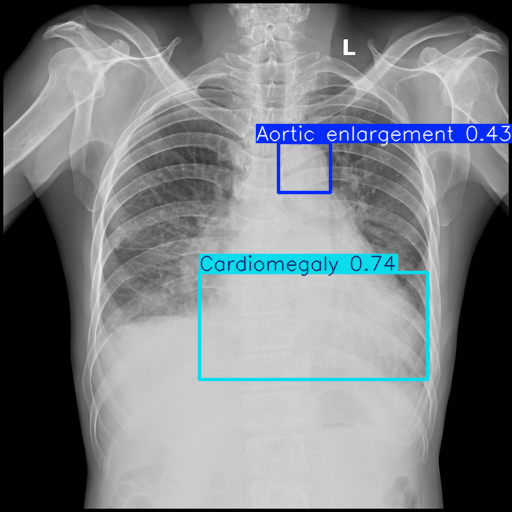

In [ ]:

# 1. Đường dẫn tới file trọng số tốt nhất
model_path = '/content/drive/MyDrive/ObjectDetection_Project/YOLO_Runs/yolov8n_cxr_test-2/weights/best.pt'

try:
    model = YOLO(model_path)
    print("Đã load model thành công!")

    # 2. Lấy ngẫu nhiên 1 bức ảnh từ tập validation
    val_images = glob.glob('/content/yolo_dataset/images/val/*.png')
    sample_img = random.choice(val_images)
    print(f"Đang dự đoán trên ảnh: {sample_img.split('/')[-1]}")

    # 3. Chạy mô hình dự đoán (Inference)
    # conf=0.25 nghĩa là chỉ vẽ các khung có độ tự tin >= 25%
    results = model.predict(source=sample_img, conf=0.25)

    # 4. Trực quan hóa kết quả
    # Hàm plot() của YOLO tự động vẽ bounding box, tên class và độ tự tin lên ảnh
    res_plotted = results[0].plot()

    # Hiển thị ảnh trên màn hình Colab
    cv2_imshow(res_plotted)

except Exception as e:
    print("Có lỗi xảy ra, vui lòng kiểm tra lại đường dẫn model_path. Chi tiết lỗi:", e)

In [ ]:

# Đảm bảo sử dụng GPU nếu có
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Đang sử dụng thiết bị: {device}")

# 1. TẠO CLASS DATASET CHUYỂN ĐỔI YOLO -> FASTER R-CNN
class CXRDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=512):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.imgs = [img for img in os.listdir(img_dir) if img.endswith('.png')]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Đọc ảnh
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1) # [C, H, W]

        # Đọc nhãn YOLO
        label_path = os.path.join(self.label_dir, img_name.replace('.png', '.txt'))
        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, cx, cy, w, h = map(float, line.strip().split())

                    # Chuyển YOLO [cx, cy, w, h] thành Pascal VOC [x_min, y_min, x_max, y_max]
                    x_min = (cx - w/2) * self.img_size
                    y_min = (cy - h/2) * self.img_size
                    x_max = (cx + w/2) * self.img_size
                    y_max = (cy + h/2) * self.img_size

                    boxes.append([x_min, y_min, x_max, y_max])


                    labels.append(int(class_id) + 1)


        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))

# Khởi tạo DataLoader
train_dataset = CXRDataset('/content/yolo_dataset/images/train', '/content/yolo_dataset/labels/train')
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

# 2. KHỞI TẠO KIẾN TRÚC FASTER R-CNN
def create_faster_rcnn_model(num_classes):
    # Load mô hình pretrained với kiến trúc ResNet50
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Lấy số lượng features ở lớp classifier cuối cùng
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Thay thế phần "đầu" (head) của mô hình bằng số lượng class mới của chúng ta
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# num_classes = 6 (5 bệnh lý + 1 nền)
faster_rcnn = create_faster_rcnn_model(num_classes=6).to(device)

print("Đã thiết lập xong kiến trúc Faster R-CNN và DataLoader!")

Đang sử dụng thiết bị: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 190MB/s]


Đã thiết lập xong kiến trúc Faster R-CNN và DataLoader!


In [ ]:
val_dataset = CXRDataset('/content/yolo_dataset/images/val', '/content/yolo_dataset/labels/val')
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
params = [p for p in faster_rcnn.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
# 2. CẤU HÌNH THƯ MỤC LƯU TRỮ
save_dir = '/content/drive/MyDrive/ObjectDetection_Project/FasterRCNN_Runs'
os.makedirs(save_dir, exist_ok=True)
# cái này ông có thời gian train lại nha ông tui chạy nhanh để kiếm bug
num_epochs = 1
best_val_loss = float('inf')

print("BẮT ĐẦU HUẤN LUYỆN FASTER R-CNN...\n" + "="*40)

for epoch in range(num_epochs):
    # --- PHASE 1: TRAINING ---
    faster_rcnn.train()
    train_loss_epoch = 0.0

    for i, (images, targets) in enumerate(train_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = faster_rcnn(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()
        train_loss_epoch += losses.item()

    avg_train_loss = train_loss_epoch / len(train_loader)

    # --- PHASE 2: VALIDATION ---

    val_loss_epoch = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Tính loss trên tập val
            loss_dict = faster_rcnn(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss_epoch += losses.item()

    avg_val_loss = val_loss_epoch / len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- PHASE 3: LƯU MÔ HÌNH TỐT NHẤT ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        save_path = os.path.join(save_dir, 'best_faster_rcnn.pth')
        torch.save(faster_rcnn.state_dict(), save_path)
        print(f" -> Đã lưu mô hình tốt nhất (Val Loss giảm xuống {best_val_loss:.4f})")

print("="*40 + "\nHOÀN TẤT HUẤN LUYỆN FASTER R-CNN!")

BẮT ĐẦU HUẤN LUYỆN FASTER R-CNN...
Epoch 1/1 | Train Loss: 0.5259 | Val Loss: 0.4623
 -> Đã lưu mô hình tốt nhất (Val Loss giảm xuống 0.4623)
HOÀN TẤT HUẤN LUYỆN FASTER R-CNN!


In [ ]:

print("Khởi tạo mô hình Transformer RT-DETR...")

model_transformer = RTDETR('rtdetr-l.pt')

print("Bắt đầu huấn luyện...")
# Cấu hình huấn luyện
results_transformer = model_transformer.train(
    data='/content/yolo_dataset/data.yaml',
    epochs=1,
    imgsz=512,
    batch=8,
    project='/content/drive/MyDrive/ObjectDetection_Project/Transformer_Runs',
    name='rtdetr_cxr_test'
)

print("Hoàn tất huấn luyện kiến trúc Transformer (RT-DETR)!")

Khởi tạo mô hình Transformer RT-DETR...
Bắt đầu huấn luyện...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_cxr_test-2, nbs=64, nms=False, o

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        1/1        14G      1.175      0.772     0.4365          7       1024: 100% ━━━━━━━━━━━━ 317/317 1.4s/it 7:20
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 2.5it/s 15.0s
                   all        608       3111      0.328      0.334      0.252      0.112

1 epochs completed in 0.129 hours.
Optimizer stripped from /content/drive/MyDrive/ObjectDetection_Project/Transformer_Runs/rtdetr_cxr_test-2/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/ObjectDetection_Project/Transformer_Runs/rtdetr_cxr_test-2/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/ObjectDetection_Project/Transformer_Runs/rtdetr_cxr_test-2/weights/best.pt...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100